# Export and flatten a Plot3D mesh with plot3d-flatten

This tutorial builds the plot3d-flatten deck format (a Plot3D grid + `connectivity.json` + `boundary_conditions.yaml` bundle for GPU CFD solvers) from a Plot3D multi-block mesh using `plot3d.glennht`.

By the end you'll know exactly what's inside a `connectivity.json` file and why -- so you can produce or debug one yourself.

## The big picture: three inputs, two producers

A GPU CFD solver consuming the plot3d-flatten deck format loads a case from
**three** artifacts:

| # | File | What it is | Who produces it |
|---|------|------------|------------------|
| (a) | `{case}.xyz` | A formatted (ASCII) Plot3D multi-block grid -- the raw node coordinates. | `plot3d.write_plot3D` |
| (b) | `{case}.connectivity.json` | The **block-level graph**: which block faces touch which other block faces, which faces are exterior boundaries (and what they physically are), and which faces are rotationally periodic. | `plot3d.glennht.write_connectivity_json` (this tutorial) |
| (c) | a run YAML's `boundary_conditions:` list | The **physics** attached to each boundary surface id -- inlet total conditions, outlet back pressure, wall thermal condition, etc. | `plot3d.glennht.write_boundary_conditions_yaml` (a fragment you paste/merge into your run deck) |

`plot3d.connectivity` and `plot3d.periodicity` compute block connectivity, exterior faces, and rotational periodicity. `plot3d.glennht` is a thin layer that serializes those results into the plot3d-flatten deck's JSON/YAML shapes.


## Install

Requires **plot3d 1.10.0+**:

```
!pip install "plot3d>=1.10.0"
```

`pymetis`/METIS isn't needed here -- that's a separate optional dependency
for partitioning large meshes across GPUs.


In [ ]:
!pip install "plot3d>=1.10.0"

## Imports

Everything used in this tutorial is importable from the top-level `plot3d`
package or from `plot3d.glennht`.


In [16]:
import json
import math
import os
import pprint

import numpy as np

from plot3d import Block
from plot3d.connectivity import connectivity, PERMUTATION_MATRICES
from plot3d.periodicity import rotated_periodicity, create_rotation_matrix
from plot3d.glennht import (
    write_connectivity_json,
    tag_surfaces_from_diagonals,
    tag_surfaces_from_bc_codes,
    tag_surfaces_geometric,
    write_bc_codes_json,
    merge_connectivity_json,
    write_boundary_conditions_yaml,
    Plot3DFlattenInletBC,
    Plot3DFlattenOutletBC,
    Plot3DFlattenWallBC,
    export_to_plot3d_flatten_deck,
)

pp = pprint.PrettyPrinter(indent=2, width=100)
OUT_DIR = "wedge_out"
os.makedirs(OUT_DIR, exist_ok=True)

## The `connectivity.json` schema, field by field

Every top-level key the plot3d-flatten deck format understands:

| Field | Type | Meaning |
|---|---|---|
| `mesh_file` | string | The paired `.xyz` grid's filename (informational/self-describing -- the run YAML's `mesh.grid_file` is what the solver actually opens). |
| `nblocks` | int | Number of blocks in the mesh. Must match the block count in `mesh_file`. |
| `face_matches` | list of face-match records | Interior, block-to-block conformal interfaces: whole faces of block A that are node-for-node coincident with a whole (or partial) face of block B. |
| `outer_faces` | list of outer-face records | Faces with **no** interior match -- i.e. the exterior boundary of the domain. Each carries an integer `id` identifying *which physical boundary surface* it belongs to (inlet, wall, ...). |
| `periodic_faces` | list of face-match records | Same shape as `face_matches`, but for pairs of faces that coincide only after a **rotation** by the blade pitch angle (rotationally-periodic seams), rather than being directly coincident. |
| `periodicity` | dict | Global periodicity metadata, required whenever `periodic_faces` is non-empty (see below). |
| `surface_ids` | dict `{"<id>": name}` | Human-readable name for every integer surface id used in `outer_faces[].id`. The run YAML's `boundary_conditions:` entries reference these same integer ids in their `surfaces:` list. |
| `permutation_matrices` | list of 8 2x2 matrices | A fixed reference copy of the 8 canonical orientation matrices (see below) -- always the same 8 matrices, included so the file (and any independent parser) is self-describing. |

The `periodicity` dict itself has these sub-fields:

| Field | Type | Meaning |
|---|---|---|
| `transformation_matrix` | 3x3 matrix | Rotation matrix such that `Face_B_points = (transformation_matrix @ Face_A_points.T).T` maps one periodic face onto its partner. |
| `rotation_angle_rad` / `rotation_angle_deg` | float | The blade pitch angle (`2*pi / nblades`), in both units for convenience. |
| `nblades` | int | Blade count for a full annulus (used to scale flow between the periodic wedge and the full machine). |
| `rotation_axis` | `"x"`\|`"y"`\|`"z"` | The machine's axis of rotation. |
| `convention` | string | States, in words, the direction the `transformation_matrix` maps (A -> B), so there's no ambiguity about which way to apply it. |
| `source` | string | Provenance -- which tool/function produced this file. |


### The diagonal (`lb`/`ub`) convention

Every face -- interior match, outer face, or periodic pair -- is stored as
two node-index corners, `lb = [i, j, k]` (lower bound) and `ub = [i, j, k]`
(upper bound). One axis is always constant (`lb[axis] == ub[axis]`), and
that axis + value tells you which of the 6 logical block faces this is:

- axis 0 (`i`) constant at `0` -> `I=1`; at `IMAX-1` -> `I=IMAX`.
- axis 1 (`j`) constant -> `J=1` or `J=JMAX`.
- axis 2 (`k`) constant -> `K=1` or `K=KMAX`.

The other two axes vary from `lb` to `ub`, describing the face's in-plane
extent.

For `face_matches`/`periodic_faces`, block1's `lb`/`ub` is always ascending,
but block2's is *directional*: it can have `lb > ub` on a varying axis to
encode a reversed traversal, without a separate "reversed" flag.

Simplest example: two blocks side by side, block 0's right side (`I=IMAX`)
touching block 1's left side (`I=1`) -- one shared face, described from
each side:

```
  +--------+--------+
  |        |        |
  | BLOCK0 | BLOCK1 |
  |        |        |
  +--------+--------+
           ^
     shared face
  block0: I=IMAX      block1: I=1
```

Both sides describe the same physical plane of nodes, just from each
block's own point of view -- exactly the `face_matches` entry you'll see
with real numbers in Step 1.


### `face_matches` vs `outer_faces` vs `periodic_faces`

These three lists partition every face into three roles:

- **`face_matches`** -- interior seams between two matched blocks; flux/state
  is exchanged directly. Found by `plot3d.connectivity.connectivity`.
- **`outer_faces`** -- true exterior boundaries (no matching neighbor). Each
  needs a physical BC, so it carries an integer `id` -- see "surface ids
  and tagging" below.
- **`periodic_faces`** -- interior seams that only coincide after rotating
  one side by the blade pitch. They start out looking like outer faces and
  get reclassified by `plot3d.periodicity.rotated_periodicity`.

`face_matches`/`periodic_faces` records share one shape:

```json
{
  "block1": {"block_index": 0, "lb": [i, j, k], "ub": [i, j, k]},
  "block2": {"block_index": 1, "lb": [i, j, k], "ub": [i, j, k]},
  "permutation_index": -1,
  "permutation_matrix": [[1, 0], [0, 1]]
}
```

`permutation_index` here is `-1` -- a "not needed" flag for this simple,
same-plane match (block2's `lb`/`ub` direction already says everything
there is to say). It can also be `4`, `5`, `6`, or `7` for a trickier
match where the two faces sit on different planes -- more on exactly what
that means in the next section.

`outer_faces` records additionally carry the surface `id`:

```json
{"block_index": 0, "lb": [i, j, k], "ub": [i, j, k], "id": 1}
```


### `permutation_index` and `permutation_matrix`

Two matched faces' `(u, v)` parametric axes might not line up: either can
be reversed, and/or swapped (a "cross-plane" match, e.g. block1 varies in
`(j, k)`, block2 in `(i, k)`). That's `2 x 2 x 2 = 8` orientations --
`plot3d.connectivity.PERMUTATION_MATRICES` is the fixed array of their
2x2 signed matrices:

```python
PERMUTATION_MATRICES = [
    [[ 1,  0], [ 0,  1]],   # 0: identity
    [[-1,  0], [ 0,  1]],   # 1: u reversed
    [[ 1,  0], [ 0, -1]],   # 2: v reversed
    [[-1,  0], [ 0, -1]],   # 3: both reversed
    [[ 0,  1], [ 1,  0]],   # 4: swapped
    [[ 0, -1], [ 1,  0]],   # 5: swap + u reversed
    [[ 0,  1], [-1,  0]],   # 6: swap + v reversed
    [[ 0, -1], [-1,  0]],   # 7: swap + both reversed
]
```

`write_connectivity_json` always writes both fields:

- `permutation_index`: `-1` for in-plane matches (0-3), because the direction
  is already encoded in block2's `lb`/`ub`. The real `4-7` value is used for
  cross-plane matches, since `lb`/`ub` can't represent an axis swap.
- `permutation_matrix`: always the actual 2x2 matrix.

The whole idea behind the permutation matrix is to provide a map:
Face B * permutation matrix = Face A


Same idea, pictured: same constant axis (top) -> 4 orientations, all
covered by lb/ub direction flips. Different constant axis, a *cross-plane*
pair (bottom) -> 8 orientations, only 4 reachable by lb/ub alone -- why the
`swapped` bit exists. Right panel: a cross-plane pair's faces walk points
in different-length strips, so a naive lb/ub traversal desyncs.


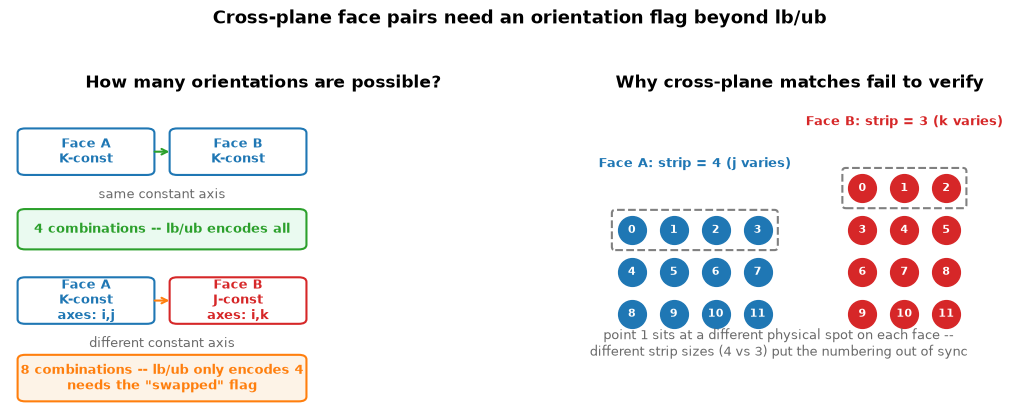

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

FACE_A, FACE_B, MATCH, NEED_SWAP = 'tab:blue', 'tab:red', 'tab:green', 'tab:orange'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Panel A: same axis (4 combos) vs cross-plane (8 combos) ---
ax = axes[0]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_title('How many orientations are possible?', fontsize=12, fontweight='bold')


def box(x, y, w, h, text, color):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle='round,pad=0.15',
        linewidth=1.5, edgecolor=color, facecolor='none'))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center',
            fontsize=9, color=color, fontweight='bold')


box(0.3, 7.6, 2.4, 1.2, 'Face A\nK-const', FACE_A)
box(3.3, 7.6, 2.4, 1.2, 'Face B\nK-const', FACE_A)
ax.annotate('', xy=(3.2, 8.2), xytext=(2.8, 8.2),
            arrowprops=dict(arrowstyle='->', color=MATCH, lw=1.5))
ax.text(3.0, 6.7, 'same constant axis', ha='center', fontsize=9, color='dimgray')
ax.add_patch(mpatches.FancyBboxPatch(
    (0.3, 5.2), 5.4, 1.0, boxstyle='round,pad=0.15',
    linewidth=1.5, edgecolor=MATCH, facecolor='#eafaf0'))
ax.text(3.0, 5.7, '4 combinations -- lb/ub encodes all',
        ha='center', va='center', fontsize=9, color=MATCH, fontweight='bold')

box(0.3, 2.8, 2.4, 1.2, 'Face A\nK-const\naxes: i,j', FACE_A)
box(3.3, 2.8, 2.4, 1.2, 'Face B\nJ-const\naxes: i,k', FACE_B)
ax.annotate('', xy=(3.2, 3.4), xytext=(2.8, 3.4),
            arrowprops=dict(arrowstyle='->', color=NEED_SWAP, lw=1.5))
ax.text(3.0, 1.9, 'different constant axis', ha='center', fontsize=9, color='dimgray')
ax.add_patch(mpatches.FancyBboxPatch(
    (0.3, 0.3), 5.4, 1.2, boxstyle='round,pad=0.15',
    linewidth=1.5, edgecolor=NEED_SWAP, facecolor='#fdf3e7'))
ax.text(3.0, 0.9,
        '8 combinations -- lb/ub only encodes 4\nneeds the "swapped" flag',
        ha='center', va='center', fontsize=9, color=NEED_SWAP, fontweight='bold')

# --- Panel B: strip-size mismatch ---
ax = axes[1]
ax.set_title('Why cross-plane matches fail to verify', fontsize=12, fontweight='bold')


def draw_grid(ax, ni, nj, color, x_off):
    n = 0
    for i in range(ni):
        for j in range(nj):
            x, y = x_off + j, ni - 1 - i
            ax.plot(x, y, 'o', color=color, markersize=20, zorder=3)
            ax.text(x, y, str(n), color='white', fontsize=8, ha='center',
                    va='center', fontweight='bold', zorder=4)
            n += 1
    rect = mpatches.FancyBboxPatch(
        (x_off - 0.4, ni - 1 - 0.4), nj - 0.2, 0.8,
        boxstyle='round,pad=0.08', linewidth=1.5,
        edgecolor='gray', facecolor='none', linestyle='--')
    ax.add_patch(rect)


ax.axis('off')
ni_a, nj_a = 3, 4  # Face A: strip of 4 (j varies)
ni_b, nk_b = 4, 3  # Face B: strip of 3 (k varies)
draw_grid(ax, ni_a, nj_a, FACE_A, x_off=0)
draw_grid(ax, ni_b, nk_b, FACE_B, x_off=nj_a + 1.5)

ax.text(nj_a / 2 - 0.5, ni_a + 0.5, 'Face A: strip = 4 (j varies)',
        ha='center', fontsize=9, color=FACE_A, fontweight='bold')
ax.text(nj_a + 1.5 + nk_b / 2 - 0.5, max(ni_a, ni_b) + 0.5,
        'Face B: strip = 3 (k varies)', ha='center', fontsize=9, color=FACE_B, fontweight='bold')

ax.text((nj_a + 1.5 + nk_b) / 2 - 0.75, -1.0,
        'point 1 sits at a different physical spot on each face --\n'
        'different strip sizes (4 vs 3) put the numbering out of sync',
        ha='center', fontsize=9, color='dimgray')

ax.set_xlim(-1, nj_a + 1.5 + nk_b + 0.5)
ax.set_ylim(-2.2, max(ni_a, ni_b) + 1.2)
ax.set_aspect('equal')

fig.suptitle('Cross-plane face pairs need an orientation flag beyond lb/ub',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Surface ids and the three tagging strategies

An `outer_faces` entry's `id` is just an integer; its meaning comes from
the `surface_ids` map, e.g.:

```json
{"1": "inlet", "2": "outlet", "3": "blade", "4": "hub", "5": "shroud"}
```

The run YAML's `boundary_conditions:` entries reference these same ids in
their `surfaces:` list. `connectivity()` leaves `id` as a meaningless
sequential counter -- you must run one of three **tagging** functions to
overwrite it with a real surface id:

| Strategy | Function | Use when |
|---|---|---|
| **Geometric** | `tag_surfaces_geometric` | Clean annular turbomachinery: classifies each outer face by its mean axial position and radius relative to the whole mesh's axial/radial extent (min-x band -> inlet, max-x band -> outlet, min-r -> hub, max-r -> shroud, everything else -> blade). Fast, no extra input needed, but assumes the machine's axis-of-rotation convention holds. |
| **BC codes** | `tag_surfaces_from_bc_codes` | You already have authoritative per-block-face integer codes (e.g. from a code-tagged legacy mesh). Exact, but requires that side information to exist. |
| **Diagonals** | `tag_surfaces_from_diagonals` | You know precisely, by hand, which `[i,j,k]` corner box on which block is which surface. Fully explicit, most tedious, always correct. |

All three mutate `outer_faces` in place and return `(outer_faces, surface_ids)`.


### What about multiple inlets or outlets?

Surfaces are just keyed by integer id -- a BC attaches to whichever ids it
lists in `surfaces: [...]`. You can have as many inlets/outlets as you
want.

Two patterns:

1. **Distinct conditions** (e.g. main inlet + cooling inlet at different
   pressure/temperature): separate id, separate BC entry each.
2. **Shared conditions** (e.g. several faces of the same inlet plenum): one
   id (or list them all in one BC's `surfaces:`).

```python
# Pattern 1: two inlets, two different sets of conditions
inlet_main = Plot3DFlattenInletBC(
    name="main_inlet", surfaces=[1],
    total_pressure=350000.0, total_temperature=450.0,
)
inlet_cooling = Plot3DFlattenInletBC(
    name="cooling_inlet", surfaces=[6],
    total_pressure=360000.0, total_temperature=320.0,
)

# Pattern 2: several faces, one shared set of conditions
inlet_shared = Plot3DFlattenInletBC(
    name="m_inlet", surfaces=[1, 7, 9],
    total_pressure=101325.0, total_temperature=288.15,
)
outlet_shared = Plot3DFlattenOutletBC(
    name="m_outlet", surfaces=[2, 8],
    back_pressure=90000.0,
)
```

**Tagging caveat**: `tag_surfaces_from_bc_codes`/`tag_surfaces_geometric`
map a *role* to one id -- fine for Pattern 2, but they can't separate two
inlets that need different conditions (they'd collapse to the same id).
Use `tag_surfaces_from_diagonals` for Pattern 1, since it assigns ids face
by face.


The two patterns above, drawn out: Pattern 1 gives each surface id its own BC entry; Pattern 2 lists several ids inside one BC entry's `surfaces:`.


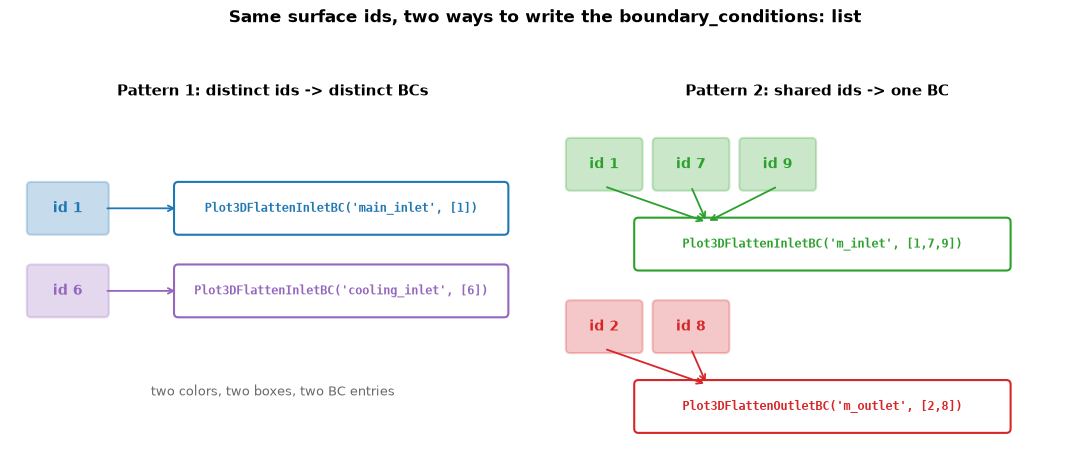

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))


def id_box(ax, x, y, label, color, w=1.4):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, 0.8, boxstyle='round,pad=0.08',
        linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.25))
    ax.text(x + w / 2, y + 0.4, label, ha='center', va='center',
            fontsize=10, color=color, fontweight='bold')


def bc_box(ax, x, y, w, label, color):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, 0.8, boxstyle='round,pad=0.08',
        linewidth=1.5, edgecolor=color, facecolor='none'))
    ax.text(x + w / 2, y + 0.4, label, ha='center', va='center',
            fontsize=8.5, color=color, fontweight='bold', family='monospace')


def arrow(ax, x0, y0, x1, y1, color):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.3))


# --- Left: Pattern 1, distinct ids, distinct BCs ---
ax = axes[0]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 6.2)
ax.set_title('Pattern 1: distinct ids -> distinct BCs', fontsize=11, fontweight='bold')

id_box(ax, 0.4, 3.9, 'id 1', 'tab:blue')
bc_box(ax, 3.2, 3.9, 6.2, "Plot3DFlattenInletBC(\'main_inlet\', [1])", 'tab:blue')
arrow(ax, 1.8, 4.3, 3.2, 4.3, 'tab:blue')

id_box(ax, 0.4, 2.4, 'id 6', 'tab:purple')
bc_box(ax, 3.2, 2.4, 6.2, "Plot3DFlattenInletBC(\'cooling_inlet\', [6])", 'tab:purple')
arrow(ax, 1.8, 2.8, 3.2, 2.8, 'tab:purple')

ax.text(5, 0.9, 'two colors, two boxes, two BC entries',
        ha='center', fontsize=9, color='dimgray')

# --- Right: Pattern 2, shared ids, one BC ---
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 6.2)
ax.set_title('Pattern 2: shared ids -> one BC', fontsize=11, fontweight='bold')

for k, sid in enumerate([1, 7, 9]):
    id_box(ax, 0.3 + k * 1.65, 4.7, f'id {sid}', 'tab:green', w=1.3)
    arrow(ax, 0.3 + k * 1.65 + 0.65, 4.7, 2.9, 4.05, 'tab:green')
bc_box(ax, 1.6, 3.25, 7.0, "Plot3DFlattenInletBC(\'m_inlet\', [1,7,9])", 'tab:green')

for k, sid in enumerate([2, 8]):
    id_box(ax, 0.3 + k * 1.65, 1.75, f'id {sid}', 'tab:red', w=1.3)
    arrow(ax, 0.3 + k * 1.65 + 0.65, 1.75, 2.9, 1.1, 'tab:red')
bc_box(ax, 1.6, 0.3, 7.0, "Plot3DFlattenOutletBC(\'m_outlet\', [2,8])", 'tab:red')

fig.suptitle('Same surface ids, two ways to write the boundary_conditions: list',
             fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


#### A concrete multi-inlet / multi-outlet example

A single inlet/outlet (the wedge built later) is the simple case -- real
machines often aren't. A cooled turbine stage might have a main gas-path
inlet plus a coolant-feed inlet, and split exit flow into core + bypass
outlets. A multistage machine has its own inlet/outlet per row (see
multi-row merge below). The mechanics don't change: every inlet/outlet is
still a `Plot3DFlattenInletBC`/`OutletBC` pointing at its `surfaces:`
id(s). Here's a four-boundary example -- two inlets, two outlets, three
walls:


In [19]:
# A cooled turbine stage with TWO inlets (main gas path + a coolant feed)
# and TWO outlets (core exit + a bypass/purge exit). Each `surfaces` id
# here would come from tagging -- reach for tag_surfaces_from_diagonals to
# give each inlet/outlet its own distinct id, since two physically-different
# inlets can't share one id (see the tagging caveat just above).
multi_io_bcs = [
    Plot3DFlattenInletBC(
        name="main_inlet", surfaces=[1],
        total_pressure=101325.0, total_temperature=288.0,
        turbulence_intensity=0.05, turbulence_length_scale=1e-3,
    ),
    Plot3DFlattenInletBC(
        name="coolant_inlet", surfaces=[6],
        total_pressure=250000.0, total_temperature=320.0,
        turbulence_intensity=0.05, turbulence_length_scale=1e-3,
    ),
    Plot3DFlattenOutletBC(name="core_outlet", surfaces=[2], back_pressure=140000.0),
    Plot3DFlattenOutletBC(name="bypass_outlet", surfaces=[7], back_pressure=120000.0),
    Plot3DFlattenWallBC(name="blade", surfaces=[3], thermal="adiabatic"),
    Plot3DFlattenWallBC(name="hub", surfaces=[4], thermal="adiabatic"),
    Plot3DFlattenWallBC(name="shroud", surfaces=[5], thermal="adiabatic"),
]

multi_io_path = os.path.join(OUT_DIR, "multi_io_boundary_conditions.yaml")
multi_io_yaml = write_boundary_conditions_yaml(multi_io_bcs, multi_io_path)
print(multi_io_yaml)

boundary_conditions:
- name: main_inlet
  type: inlet
  surfaces: [1]
  total_pressure: 101325.0
  total_temperature: 288.0
  turbulence_intensity: 0.05
  turbulence_length_scale: 0.001
- name: coolant_inlet
  type: inlet
  surfaces: [6]
  total_pressure: 250000.0
  total_temperature: 320.0
  turbulence_intensity: 0.05
  turbulence_length_scale: 0.001
- name: core_outlet
  type: outlet
  surfaces: [2]
  back_pressure: 140000.0
- name: bypass_outlet
  type: outlet
  surfaces: [7]
  back_pressure: 120000.0
- name: blade
  type: wall
  surfaces: [3]
  thermal: adiabatic
- name: hub
  type: wall
  surfaces: [4]
  thermal: adiabatic
- name: shroud
  type: wall
  surfaces: [5]
  thermal: adiabatic



`main_inlet`/`coolant_inlet` and `core_outlet`/`bypass_outlet` above are
**Pattern 1** -- distinct ids, distinct BCs. If they'd shared conditions,
**Pattern 2** would apply: one BC, `surfaces=[1, 6]`.

Multistage/mixing-plane machines are the most common source of many
inlets/outlets: each row gets its own, and
`merge_connectivity_json(..., id_stride=100)` (Step 8) turns row 1's ids
`1..5` into `101..105`, row 2's into `201..205`, etc. A row-to-row seam is
then an outlet BC and inlet BC that name each other via
`mixing_plane_partner`.


### The `bc_codes.json` sidecar

`write_bc_codes_json` writes a companion file with the raw per-block,
per-face integer codes a `bc_codes` tagging decision was based on -- an
audit trail, and the input format `tag_surfaces_from_bc_codes` expects.
One row of 6 integers per block, fixed face order:

```
FACE_ORDER = ["I=1", "I=IMAX", "J=1", "J=JMAX", "K=1", "K=KMAX"]
```

Legend:

| Code | Meaning |
|---|---|
| 5 | inlet |
| 6 | outlet |
| 10 | blade |
| 9 | hub |
| 109 | shroud |
| 13 | periodic (low side) |
| 14 | periodic (high side) |
| 0 | interior interface |

Excerpt of a `bc_codes.json` (5-block stator row):

```json
{
  "face_order": ["I=1", "I=IMAX", "J=1", "J=JMAX", "K=1", "K=KMAX"],
  "blocks": [
    [5, 6, 0, 14, 9, 109],
    [5, 6, 13, 0, 9, 109],
    [0, 0, 10, 0, 9, 109],
    ...
  ],
  "block_order": ["S35#0001", "S35#0002", ...]
}
```

Code `0` (interior interface) on a face `tag_surfaces_from_bc_codes` can't
find in `outer_faces` (already matched) is a no-op. Code `0` on a face
still in `outer_faces` (connectivity missed the match) maps to id **8**,
`unmatched_interface` -- flagged distinctly, not silently made a wall, so
you notice and fix the mesh.

Codes `13`/`14` are a safety net: run `rotated_periodicity` first (it
splits real periodic seams into `periodic_faces`), then tag what's left
with `bc_codes`. Any face still coded `13`/`14` means periodicity
detection missed it -- it gets tagged id **6**, `periodic`, instead of
silently becoming a wall.


### The `boundary_conditions:` YAML -- physics, not topology

`connectivity.json` only says *where* the boundaries are (integer ids).
The physics goes in the run YAML's `boundary_conditions:` list, each entry
keyed by `type` and linked to `connectivity.json` via `surfaces: [ids]`.
`plot3d.glennht.plot3d_flatten_bc` gives three small dataclasses for this:

```python
Plot3DFlattenInletBC(
    name, surfaces,
    total_pressure, total_temperature,             # required
    flow_angle_deg=None, turbulence_intensity=None, turbulence_length_scale=None,
    blades_full_ring=None,                          # blade count, for pitch scaling
    inlet_subtype=None, mixing_plane_partner=None,  # mixing-plane interface
)

Plot3DFlattenOutletBC(
    name, surfaces,
    back_pressure,                                  # required
    extrapolation_order=None, mixing_plane_partner=None, blades_full_ring=None,
)

Plot3DFlattenWallBC(
    name, surfaces,
    thermal="adiabatic",                            # or set wall_temperature/wall_heat_flux
    wall_temperature=None, wall_heat_flux=None,
    rotating=None,                                  # spins with its row's frame
)
```

Every dataclass has a `surfaces: List[int]` field, and only fields you set
get emitted (`to_dict()` skips `None`) -- a plain wall stays 3-4 lines.
`write_boundary_conditions_yaml(bcs, filename, rotation=...)` serializes a
list of these to YAML, optionally with a top-level `rotation:` block
(per-block angular velocity).

For a **multi-row** machine, a mixing-plane interface pairs one row's
outlet with the next row's inlet by name (`mixing_plane_partner`), each
scaled by its own `blades_full_ring` (e.g. 36 rotor, 46 stator) so flow
conserves across the pitch change:

```yaml
boundary_conditions:
  - name: rotor35_out
    type: outlet
    surfaces: [2]
    back_pressure: 140293.8
    mixing_plane_partner: stator35_in
    blades_full_ring: 36

  - name: stator35_in
    type: inlet
    surfaces: [101]
    inlet_subtype: mixing_plane
    mixing_plane_partner: rotor35_out
    total_pressure: 140293.8
    total_temperature: 359.0
    blades_full_ring: 46
```

Notice the stator's inlet surface id is **101**, not 1 -- which brings us to
multi-row merging.


### Multi-row merge: why ids get a per-row offset

A multistage machine is usually meshed and connectivity-analyzed **one row
at a time**, producing a `{row}.connectivity.json` per row. The per-row
grids are concatenated into one `.xyz` (rotor blocks, then stator blocks),
and `merge_connectivity_json` combines the JSON payloads to match:

- `block_index` in every list is shifted by the running block total from
  prior rows;
- `outer_faces[].id` is shifted by `id_stride * row` (default `100`) --
  row 0 keeps `1..5`, row 1 becomes `101..105`, row 2 `201..205`, etc.;
- each row's `periodic_faces` keep *that row's* `rotation_angle_rad`,
  since blade counts (and pitch) differ per row;
- the merged file's top-level `periodicity` is just row 0's, a fallback
  default -- the real per-seam angle lives on each `periodic_faces` entry.

Row-to-row interior seams (the mixing-plane interface) are **not**
produced by this merge -- they need their own connectivity/periodicity
pass if conformal, or stay as two independent `outer_faces` (a
mixing-plane inlet/outlet pair) if not, as in the example above (surfaces
`2` and `101` coupled only via the solver's mixing-plane BC).


## A runnable example: a two-block annular wedge

To make this concrete -- and fast on Colab's free tier -- we'll build a
tiny **annular wedge**: two blocks stacked along `x`, each spanning a
fixed hub-to-shroud radius and a small wedge angle `dtheta` in `theta`.
This produces every face type we want to demonstrate:

- an **interior match** where the blocks meet (shared `x` plane),
- **inlet**/**outlet** faces at the two open `x` ends,
- **hub**/**shroud** faces at min/max radius,
- a **rotationally-periodic** pair on each block's two `theta` faces.

With `dtheta = 20 deg`, `nblades = 360/20 = 18` -- a 1/18th slice of a
full annulus.


In [20]:
def wedge_block(x0, x1, nx, r_hub=0.2, r_shroud=0.3, nr=9, dtheta=np.radians(20.0), nt=13):
    x = np.linspace(x0, x1, nx)
    r = np.linspace(r_hub, r_shroud, nr)
    th = np.linspace(0.0, dtheta, nt)
    X = np.zeros((nx, nr, nt))
    Y = np.zeros_like(X)
    Z = np.zeros_like(X)
    for i in range(nx):
        for j in range(nr):
            for k in range(nt):
                X[i, j, k] = x[i]
                Y[i, j, k] = r[j] * np.cos(th[k])
                Z[i, j, k] = r[j] * np.sin(th[k])
    return Block(X, Y, Z)

dtheta = np.radians(20.0)
nblades = round(2 * np.pi / dtheta)  # 18

# Two blocks stacked along x, sharing the x=0.5 face
blocks = [wedge_block(0.0, 0.5, 15), wedge_block(0.5, 1.0, 15)]

print(f"nblades = {nblades}")
print("blocks:", [(b.IMAX, b.JMAX, b.KMAX) for b in blocks])

nblades = 18
blocks: [(15, 9, 13), (15, 9, 13)]


### Visualizing the mesh

Before computing connectivity, let's *see* what we built: an **annular
wedge** (one blade passage) split into **2 blocks** along `x`.
`plot_blocks` draws each block in a different color.


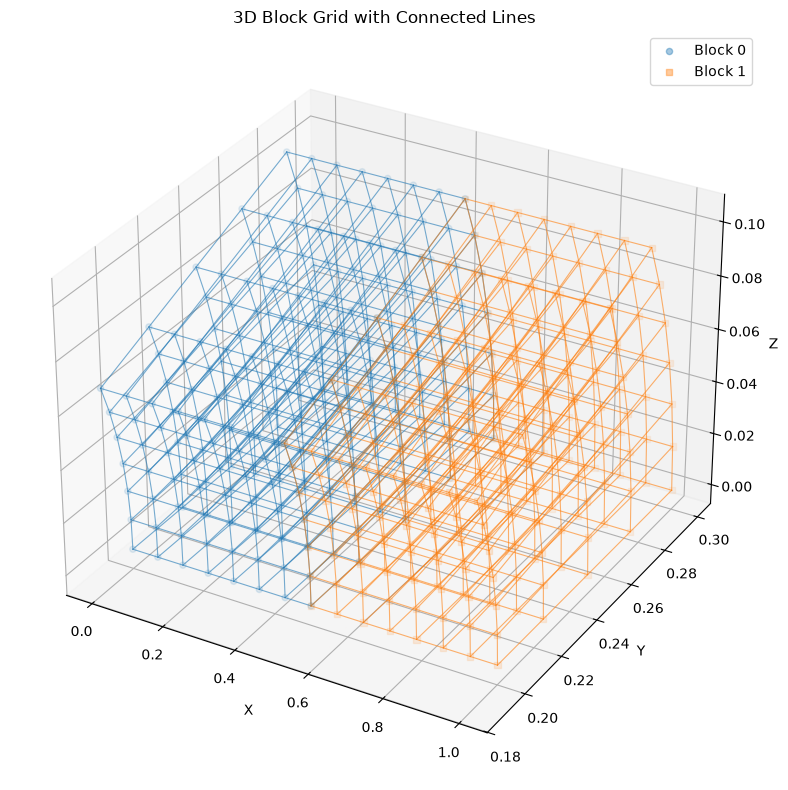

In [6]:
from plot3d import plot_blocks

plot_blocks(blocks)

## Step 1: Full connectivity

We use `plot3d.connectivity.connectivity`, **not** `connectivity_fast`.
`connectivity_fast` reduces blocks by their common GCD to speed up
matching -- fine for huge regular meshes, but it can silently *drop* real
matches on O-grids/H-split topologies. This isn't theoretical: on a real
stator mesh, the fast path has dropped half the real face matches,
mis-tagging them as exterior. A missed interior match becomes a phantom
wall the solver wrongly no-slips -- so for graph export, always use the
full `connectivity()`.

`connectivity()` returns `(face_matches, outer_faces)`. Our two blocks
meet at one interior interface (shared `x=0.5` plane), so
`len(face_matches) == 1`.


In [31]:
face_matches, outer_faces = connectivity(blocks)

print(f"face_matches found: {len(face_matches)}")
print(f"outer_faces found:  {len(outer_faces)}")

Checking connections block 0 with 1: 100%|██████████| 1/1 [00:00<00:00, 25.27it/s]

Phase 3: Fresh-face validation...
  Phase 3 done (0 new matches)
face_matches found: 1
outer_faces found:  10


Block1's `lb`/`ub` is `[14,0,0]` to `[14,8,12]` -- `i` constant at `14`
(`IMAX-1`), block0's **`I=IMAX`** face. Block2's is `[0,0,0]` to
`[0,8,12]` -- `i=0`, block1's **`I=1`** face. Same shared `x=0.5` plane,
from each side. `permutation_index=-1` / `plane='in-plane'` confirms a
plain, non-swapped match -- expected, since both blocks used identical
nested loops.


In [22]:
fm0 = dict(face_matches[0])
fm0.pop("match", None)  # internal pandas DataFrame, not part of the exported schema
pp.pprint(fm0)

{ 'block1': {'block_index': 0, 'id': 0, 'lb': [14, 0, 0], 'ub': [14, 8, 12]},
  'block2': {'block_index': 1, 'id': 0, 'lb': [0, 0, 0], 'ub': [0, 8, 12]},
  'orientation': { 'permutation_index': -1,
                   'permutation_matrix': [[1, 0], [0, 1]],
                   'plane': 'in-plane'}}


Ten raw `outer_faces` (6 sides per block, minus 1 consumed by the
interior match = 5 x 2). **Important**: `id` here is just a sequential
discovery-order counter -- no physical meaning yet. The `tag_surfaces_*`
functions below overwrite it with a real surface id.


In [23]:
for f in outer_faces[:3]:
    pp.pprint(f)

{'block_index': 0, 'id': 1, 'lb': [0, 0, 0], 'ub': [14, 0, 12]}
{'block_index': 1, 'id': 2, 'lb': [0, 0, 0], 'ub': [14, 0, 12]}
{'block_index': 0, 'id': 3, 'lb': [0, 8, 0], 'ub': [14, 8, 12]}


## Step 2: Rotational periodicity

Next, peel the rotationally-periodic seam off `outer_faces` with
`rotated_periodicity`, **before** tagging (what
`export_to_plot3d_flatten_deck` does internally). This ordering is what
makes the `bc_codes` "leftover periodic -> id 6" fallback meaningful.

`rotated_periodicity`'s `rotation_angle` is in **degrees**
(`create_rotation_matrix`, used next, takes **radians** -- watch the
units).

We expect 2 periodic pairs: each block's own `K=1`/`K=KMAX` theta faces
match after rotating by `dtheta` -- a self-match, since each block spans
the full wedge angle.


In [24]:
periodic_faces, outer_faces, _, _ = rotated_periodicity(
    blocks, face_matches, outer_faces,
    rotation_angle=math.degrees(dtheta), rotation_axis="x",
)

print(f"periodic_faces found: {len(periodic_faces)}")
print(f"outer_faces remaining: {len(outer_faces)}")

Blk 0 <-> 0 | found 0:   2%|▏         | 2/90 [00:00<00:00, 662.24it/s]
Blk 1 <-> 1 | found 1:  11%|█         | 6/56 [00:00<00:00, 1643.32it/s]
Blk 1 <-> 0 | found 2: 100%|██████████| 26/26 [00:00<00:00, 1783.03it/s]

periodic_faces found: 2
outer_faces remaining: 6


In [25]:
pf0 = dict(periodic_faces[0])
pf0.pop("match", None)
pp.pprint(pf0)

{ 'block1': {'block_index': 0, 'id': 4, 'lb': [0, 0, 12], 'ub': [14, 8, 12]},
  'block2': {'block_index': 0, 'id': 8, 'lb': [0, 0, 0], 'ub': [14, 8, 0]},
  'orientation': { 'permutation_index': -1,
                   'permutation_matrix': [[1, 0], [0, 1]],
                   'plane': 'in-plane'}}


Block1 here is block0's `K=KMAX` face (`k=12` constant); block2 is the
*same block's* `K=1` face (`k=0` constant) -- confirming the self-match.
Only 6 outer faces remain: 1 inlet, 1 outlet, 2 hub, 2 shroud.


### Visualizing block connectivity and periodicity

With `face_matches` and `periodic_faces` both computed, let's see *where*
they are. Both blocks are drawn as light, transparent context, with the
interface and periodic faces highlighted in bold color.


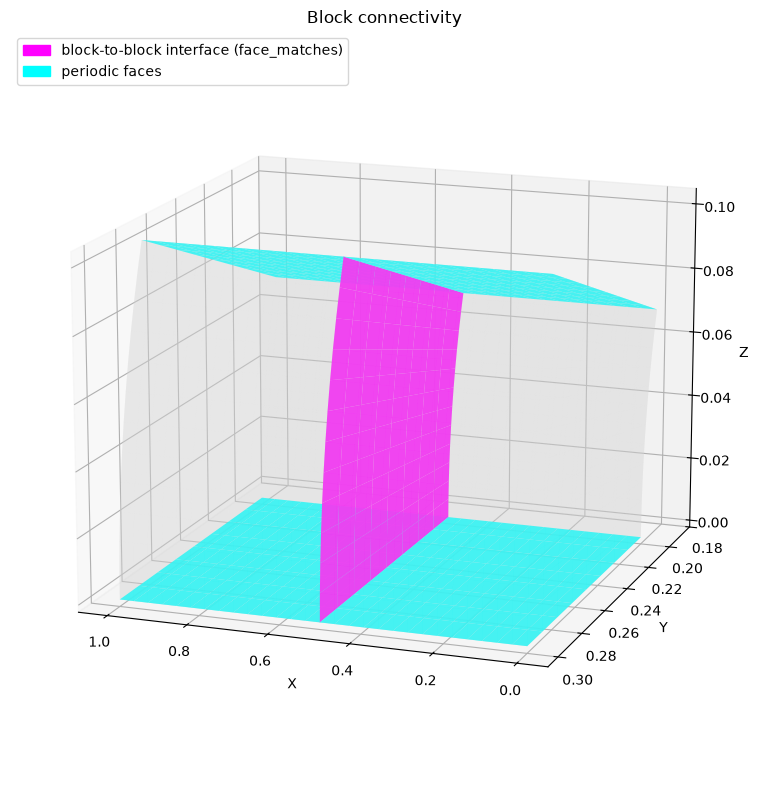

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D


def _face_coords(block, lb, ub):
    i0, i1 = sorted((lb[0], ub[0]))
    j0, j1 = sorted((lb[1], ub[1]))
    k0, k1 = sorted((lb[2], ub[2]))
    X = block.X[i0:i1 + 1, j0:j1 + 1, k0:k1 + 1]
    Y = block.Y[i0:i1 + 1, j0:j1 + 1, k0:k1 + 1]
    Z = block.Z[i0:i1 + 1, j0:j1 + 1, k0:k1 + 1]
    # squeeze the collapsed (size-1) axis so we get 2D arrays for plot_surface
    return np.squeeze(X), np.squeeze(Y), np.squeeze(Z)


def _block_face_specs(block):
    """lb/ub diagonals for all 6 logical faces (I=1, I=IMAX, ...) of a block."""
    ni, nj, nk = block.IMAX - 1, block.JMAX - 1, block.KMAX - 1
    return [
        ([0, 0, 0], [0, nj, nk]),
        ([ni, 0, 0], [ni, nj, nk]),
        ([0, 0, 0], [ni, 0, nk]),
        ([0, nj, 0], [ni, nj, nk]),
        ([0, 0, 0], [ni, nj, 0]),
        ([0, 0, nk], [ni, nj, nk]),
    ]


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Light gray context: every block's full outer envelope (all 6 logical faces), low alpha
for block in blocks:
    for lb, ub in _block_face_specs(block):
        try:
            X, Y, Z = _face_coords(block, lb, ub)
            ax.plot_surface(X, Y, Z, color='lightgray', alpha=0.25, shade=False, linewidth=0)
        except Exception as e:
            print(f"warning: skipped context face {lb}-{ub}: {e}")

# Bold magenta: block-to-block interfaces (face_matches), drawn from block1's side
for m in face_matches:
    try:
        b1 = blocks[m['block1']['block_index']]
        X, Y, Z = _face_coords(b1, m['block1']['lb'], m['block1']['ub'])
        ax.plot_surface(X, Y, Z, color='magenta', alpha=0.9, shade=False)
    except Exception as e:
        print(f"warning: skipped face_matches entry: {e}")

# Bold cyan: rotationally-periodic faces, both sides of each pair
if periodic_faces:
    for pf in periodic_faces:
        for side in ('block1', 'block2'):
            try:
                b = blocks[pf[side]['block_index']]
                X, Y, Z = _face_coords(b, pf[side]['lb'], pf[side]['ub'])
                ax.plot_surface(X, Y, Z, color='cyan', alpha=0.9, shade=False)
            except Exception as e:
                print(f"warning: skipped periodic_faces entry ({side}): {e}")
else:
    print("No periodic_faces to draw.")

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Block connectivity')
ax.view_init(elev=15, azim=110)

legend_handles = [
    mpatches.Patch(color='magenta', label='block-to-block interface (face_matches)'),
    mpatches.Patch(color='cyan', label='periodic faces'),
]
ax.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.show()

**Magenta** = the single interior interface from `face_matches` -- the
shared `x=0.5` plane, an **interior face, not a boundary condition**.
**Cyan** = the `periodic_faces` pair -- each block's own `K=1`/`K=KMAX`
faces, related by a `dtheta` rotation. Periodicity here is a *self*-match
within each block, not between the two blocks.


## Step 3: Tag the remaining outer faces

### Geometric tagging (the strategy we'll use for the final file)

`tag_surfaces_geometric` looks at each outer face's mean axial position
and radius, compares against the global extent, and classifies: min-x ->
**inlet** (1), max-x -> **outlet** (2), min-radius -> **hub** (4),
max-radius -> **shroud** (5), else -> **blade** (3). We work on a copy to
compare strategies side by side below.


In [27]:
outer_faces_geo = [dict(f) for f in outer_faces]
outer_faces_geo, surface_ids = tag_surfaces_geometric(blocks, outer_faces_geo, axis="x")

print("surface_ids:", surface_ids)
for f in outer_faces_geo:
    pp.pprint(f)

surface_ids: {'1': 'inlet', '2': 'outlet', '3': 'blade', '4': 'hub', '5': 'shroud'}
{'block_index': 0, 'id': 4, 'lb': [0, 0, 0], 'ub': [14, 0, 12]}
{'block_index': 1, 'id': 4, 'lb': [0, 0, 0], 'ub': [14, 0, 12]}
{'block_index': 0, 'id': 5, 'lb': [0, 8, 0], 'ub': [14, 8, 12]}
{'block_index': 1, 'id': 5, 'lb': [0, 8, 0], 'ub': [14, 8, 12]}
{'block_index': 1, 'id': 2, 'lb': [14, 0, 0], 'ub': [14, 8, 12]}
{'block_index': 0, 'id': 1, 'lb': [0, 0, 0], 'ub': [0, 8, 12]}


### Visualizing the boundary conditions

Now that every outer face has a real `id`, let's draw each as a colored
3D patch. This is the picture of what `outer_faces_geo`/`surface_ids`
describe -- the **most important** plot in this tutorial, since it's what
you should check before trusting any `connectivity.json` you generate.


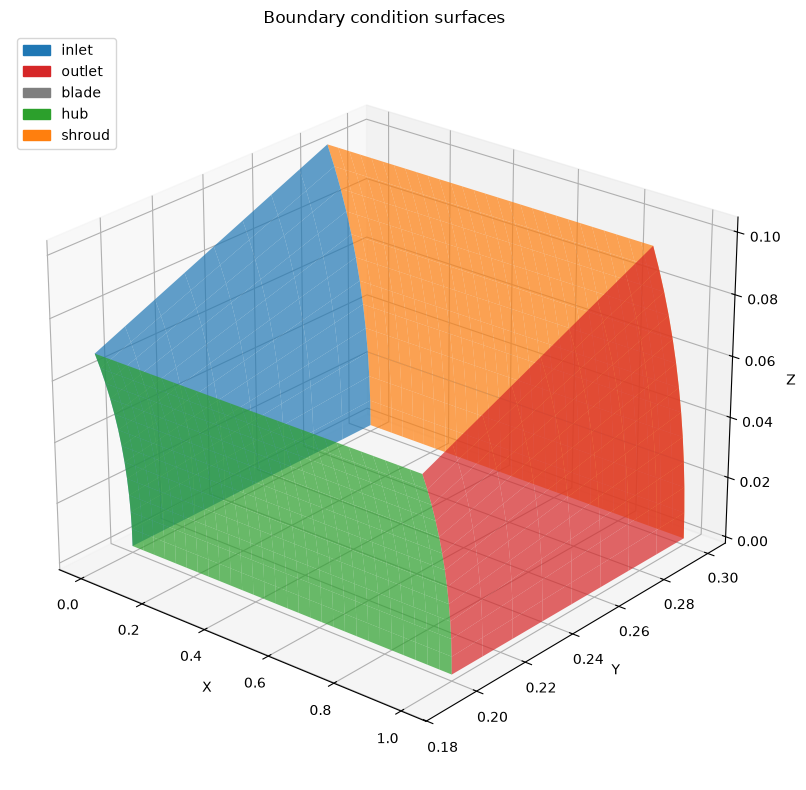

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D


def _face_coords(block, lb, ub):
    i0, i1 = sorted((lb[0], ub[0]))
    j0, j1 = sorted((lb[1], ub[1]))
    k0, k1 = sorted((lb[2], ub[2]))
    X = block.X[i0:i1 + 1, j0:j1 + 1, k0:k1 + 1]
    Y = block.Y[i0:i1 + 1, j0:j1 + 1, k0:k1 + 1]
    Z = block.Z[i0:i1 + 1, j0:j1 + 1, k0:k1 + 1]
    # squeeze the collapsed (size-1) axis so we get 2D arrays for plot_surface
    return np.squeeze(X), np.squeeze(Y), np.squeeze(Z)


# Prefer well-known colors for well-known surface names; fall back to
# the default matplotlib color cycle for anything else, so this works
# for any surface_ids map (e.g. one that also has a 'blade' surface).
_preferred_colors = {
    'inlet': 'tab:blue',
    'outlet': 'tab:red',
    'hub': 'tab:green',
    'shroud': 'tab:orange',
    'blade': 'tab:gray',
}
_fallback_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
surface_colors = {}
for idx, (sid, name) in enumerate(surface_ids.items()):
    surface_colors[int(sid)] = _preferred_colors.get(name, _fallback_cycle[idx % len(_fallback_cycle)])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for f in outer_faces_geo:
    try:
        block = blocks[f['block_index']]
        X, Y, Z = _face_coords(block, f['lb'], f['ub'])
        color = surface_colors.get(f['id'], 'black')
        ax.plot_surface(X, Y, Z, color=color, alpha=0.7, shade=False)
    except Exception as e:
        print(f"warning: skipped outer face {f}: {e}")

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Boundary condition surfaces')
ax.view_init(elev=25, azim=-50)

legend_handles = [
    mpatches.Patch(color=surface_colors[int(sid)], label=name)
    for sid, name in surface_ids.items()
]
ax.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.show()

For this wedge, `surface_ids` (and the colors above) are:

- **blue** = `inlet` (id 1)
- **red** = `outlet` (id 2)
- **gray** = `blade` (id 3) -- in `surface_ids` by default, but unused
  here (no airfoil surface).
- **green** = `hub` (id 4)
- **orange** = `shroud` (id 5)

These are the same ids a run YAML's `boundary_conditions:` entries
reference in `surfaces:` (Step 6) -- `surfaces: [1]` targets the blue
patch above.


As expected: `j=0` faces got `id=4` (hub), `j=JMAX` got `id=5` (shroud),
min-x got `id=1` (inlet), max-x got `id=2` (outlet). No `blade` (id 3)
here -- this wedge has no airfoil surface.

### Diagonals tagging (explicit, one face at a time)

`tag_surfaces_from_diagonals` is the manual alternative: specify the exact
`[i,j,k]` corner box yourself. Useful when geometry can't disambiguate
(e.g. two inlets at similar axial stations), or to force one surface
without touching the rest. Here we re-tag block0's inlet face by its exact
diagonal:


In [29]:
outer_faces_diag = [dict(f) for f in outer_faces]  # fresh copy, untagged
inlet_face = [f for f in outer_faces_diag
              if f["block_index"] == 0 and f["lb"][0] == f["ub"][0] == 0][0]
print("face to tag:", inlet_face)

specs = [{
    "block_index": 0,
    "lb": inlet_face["lb"],
    "ub": inlet_face["ub"],
    "id": 1,
    "name": "inlet",
}]
outer_faces_diag, surface_ids_diag = tag_surfaces_from_diagonals(blocks, outer_faces_diag, specs)
print("surface_ids:", surface_ids_diag)
print("tagged face:", [f for f in outer_faces_diag if f.get("id") is not None])

face to tag: {'lb': [0, 0, 0], 'ub': [0, 8, 12], 'id': 10, 'block_index': 0}
surface_ids: {'1': 'inlet'}
tagged face: [{'lb': [0, 0, 0], 'ub': [14, 0, 12], 'id': 1, 'block_index': 0}, {'lb': [0, 0, 0], 'ub': [14, 0, 12], 'id': 2, 'block_index': 1}, {'lb': [0, 8, 0], 'ub': [14, 8, 12], 'id': 3, 'block_index': 0}, {'lb': [0, 8, 0], 'ub': [14, 8, 12], 'id': 5, 'block_index': 1}, {'lb': [14, 0, 0], 'ub': [14, 8, 12], 'id': 7, 'block_index': 1}, {'lb': [0, 0, 0], 'ub': [0, 8, 12], 'id': 1, 'block_index': 0}]


### BC-codes tagging (from authoritative per-block face codes)

`tag_surfaces_from_bc_codes` takes one 6-integer row per block in
`FACE_ORDER = ["I=1", "I=IMAX", "J=1", "J=JMAX", "K=1", "K=KMAX"]`. We
hand-build codes as if from a legacy code-tagged mesh: block 0's `I=1` is
inlet (`5`); `I=IMAX` is the interior interface (`0`, already matched, so
never looked up); `J=1`/`J=JMAX` are hub/shroud (`9`/`109`); `K=1`/`K=KMAX`
are marked periodic (`13`/`14`) -- already removed from `outer_faces` by
`rotated_periodicity`, so those find nothing to tag, as predicted.


In [30]:
# FACE_ORDER = [I=1, I=IMAX, J=1, J=JMAX, K=1, K=KMAX]
bc_codes = [
    [5, 0, 9, 109, 13, 14],   # block 0: inlet, interface, hub, shroud, periodic, periodic
    [0, 6, 9, 109, 13, 14],   # block 1: interface, outlet, hub, shroud, periodic, periodic
]

outer_faces_bc = [dict(f) for f in outer_faces]  # fresh copy, untagged
outer_faces_bc, surface_ids_bc = tag_surfaces_from_bc_codes(blocks, outer_faces_bc, bc_codes)

print("surface_ids:", surface_ids_bc)
for f in outer_faces_bc:
    pp.pprint(f)

surface_ids: {'1': 'inlet', '2': 'outlet', '3': 'blade', '4': 'hub', '5': 'shroud', '6': 'periodic', '8': 'unmatched_interface'}
{'block_index': 0, 'id': 4, 'lb': [0, 0, 0], 'ub': [14, 0, 12]}
{'block_index': 1, 'id': 4, 'lb': [0, 0, 0], 'ub': [14, 0, 12]}
{'block_index': 0, 'id': 5, 'lb': [0, 8, 0], 'ub': [14, 8, 12]}
{'block_index': 1, 'id': 5, 'lb': [0, 8, 0], 'ub': [14, 8, 12]}
{'block_index': 1, 'id': 2, 'lb': [14, 0, 0], 'ub': [14, 8, 12]}
{'block_index': 0, 'id': 1, 'lb': [0, 0, 0], 'ub': [0, 8, 12]}


Same result as the geometric pass (ids 1/2/4/5) -- three roads, same
answer here. Now write the `bc_codes.json` sidecar:


In [ ]:
bc_codes_path = os.path.join(OUT_DIR, "wedge.bc_codes.json")
bc_codes_payload = write_bc_codes_json(
    blocks, bc_codes, bc_codes_path,
    block_order=["wedge_block_0", "wedge_block_1"],
)
print(json.dumps(bc_codes_payload, indent=2))

## Step 4: The periodicity transformation matrix

`create_rotation_matrix(rotation_angle, rotation_axis)` builds the 3x3
matrix for `periodicity.transformation_matrix` -- **radians** this time
(unlike `rotated_periodicity` above). We assemble the full `periodicity`
dict by hand so you see every field `write_connectivity_json` expects;
it's required whenever `periodic_faces` is non-empty.


In [ ]:
transformation_matrix = create_rotation_matrix(dtheta, "x")
print(transformation_matrix)

In [ ]:
periodicity_meta = {
    "nblades": int(nblades),
    "rotation_axis": "x",
    "rotation_angle_rad": float(dtheta),
    "rotation_angle_deg": float(math.degrees(dtheta)),
    "transformation_matrix": transformation_matrix.tolist(),
    "convention": "Face_B_points = (transformation_matrix @ Face_A_points.T).T",
}
pp.pprint(periodicity_meta)

## Step 5: Write `connectivity.json`

We have every ingredient: `face_matches` (1 seam), `outer_faces_geo` (6
tagged faces), `periodic_faces` (2 pairs), `periodicity_meta`.
`write_connectivity_json` folds these into the final payload, filling in
`mesh_file`/`nblocks`/`permutation_matrices` automatically -- we'll reload
it from disk to prove the round-trip.


In [ ]:
conn_path = os.path.join(OUT_DIR, "wedge.connectivity.json")
payload = write_connectivity_json(
    blocks,
    face_matches,
    outer_faces_geo,
    conn_path,
    periodic_faces=periodic_faces,
    periodicity=periodicity_meta,
    surface_ids=surface_ids,
    mesh_file="wedge.xyz",
)

with open(conn_path) as fh:
    reloaded = json.load(fh)

# NOTE: we deliberately don't `print(json.dumps(reloaded, indent=2))` the
# whole payload here -- `permutation_matrices` alone is a fixed 8-entry
# table of 2x2 matrices that, once pretty-printed, buries every other field
# under a wall of nested brackets. Instead, print each part in the format
# that's actually readable for it: a summary line for the top level, one
# compact (single-line) JSON dict per example record, and the small fixed
# tables printed directly.
print("top-level keys:", list(reloaded.keys()))
print(f"nblocks: {reloaded['nblocks']}")
print(f"face_matches: {len(reloaded['face_matches'])}  "
      f"outer_faces: {len(reloaded['outer_faces'])}  "
      f"periodic_faces: {len(reloaded.get('periodic_faces', []))}")
print("surface_ids:", reloaded["surface_ids"])

print("\nexample face_match:")
print(json.dumps(reloaded["face_matches"][0]))            # compact, one line

print("\nexample outer_face:")
print(json.dumps(reloaded["outer_faces"][0]))              # compact, one line

print("\nperiodicity:")
print(json.dumps(reloaded["periodicity"], indent=2))

print("\npermutation_matrices (8 fixed 2x2 signed permutations):")
for m in reloaded["permutation_matrices"]:
    print("  ", m)                                          # one matrix per line

### Dissecting this file against the schema table

Match this back to the schema table above, field by field:

- **`mesh_file: "wedge.xyz"`**, **`nblocks: 2`** -- as given.
- **`face_matches`**: 1 seam -- block0's `I=IMAX` (`lb=[14,0,0]`,
  `ub=[14,8,12]`) matched to block1's `I=1` (`lb=[0,0,0]`, `ub=[0,8,12]`),
  `permutation_index: -1`, identity matrix -- in-plane, non-reversed, as
  expected.
- **`outer_faces`**: the 6 tagged faces from Step 3 -- two `id:4` (hub),
  two `id:5` (shroud), one `id:2` (outlet), one `id:1` (inlet). The
  transient discovery counter is gone; only the real surface id remains.
- **`periodic_faces`**: both self-matches from Step 2 (block0's and
  block1's `K=KMAX` <-> `K=1`), each with `permutation_index`/
  `permutation_matrix` but **no `id`** -- `id` only belongs on
  `outer_faces`.
- **`periodicity`**: our `periodicity_meta` dict, plus an auto-filled
  `source` string (since we didn't supply one).
- **`surface_ids`** is the `{"1": "inlet", ..., "5": "shroud"}` map from
  the geometric tagging pass.
- **`permutation_matrices`**: the fixed reference copy of all 8 canonical
  matrices, present in every file this exporter writes.


## Step 6: Boundary-condition physics

With topology written, attach physics to ids 1 (inlet), 2 (outlet), 4
(hub), 5 (shroud) using the three BC dataclasses. No blade surface (id 3)
here -- just one inlet, one outlet, two stationary walls.


In [34]:
bcs = [
    Plot3DFlattenInletBC(
        name="wedge_inlet",
        surfaces=[1],
        total_pressure=101325.0,
        total_temperature=288.15,
        turbulence_intensity=0.02,
        turbulence_length_scale=0.001,
        blades_full_ring=nblades,
    ),
    Plot3DFlattenOutletBC(
        name="wedge_outlet",
        surfaces=[2],
        back_pressure=100000.0,
        blades_full_ring=nblades,
    ),
    Plot3DFlattenWallBC(name="wedge_hub", surfaces=[4], thermal="adiabatic", rotating=False),
    Plot3DFlattenWallBC(name="wedge_shroud", surfaces=[5], thermal="adiabatic", rotating=False),
]

bc_yaml_path = os.path.join(OUT_DIR, "wedge_boundary_conditions.yaml")
yaml_text = write_boundary_conditions_yaml(bcs, bc_yaml_path)
print(yaml_text)

boundary_conditions:
- name: wedge_inlet
  type: inlet
  surfaces: [1]
  total_pressure: 101325.0
  total_temperature: 288.15
  turbulence_intensity: 0.02
  turbulence_length_scale: 0.001
  blades_full_ring: 18
- name: wedge_outlet
  type: outlet
  surfaces: [2]
  back_pressure: 100000.0
  blades_full_ring: 18
- name: wedge_hub
  type: wall
  surfaces: [4]
  thermal: adiabatic
  rotating: false
- name: wedge_shroud
  type: wall
  surfaces: [5]
  thermal: adiabatic
  rotating: false



Only the fields we set appear -- unset ones (e.g. `wall_temperature`) are
absent, not `null`. Paste this fragment into your run config's
`boundary_conditions:` list.


## Step 7: The one-call driver, `export_to_plot3d_flatten_deck`

Everything above -- connectivity, periodicity, tagging, writing the
grid/JSON/YAML -- is what `export_to_plot3d_flatten_deck` does internally,
in one call. It always uses full `connectivity()` (never `_fast`) and runs
periodicity before tagging. This is the call you'd use day to day:


In [35]:
paths = export_to_plot3d_flatten_deck(
    blocks,
    OUT_DIR,
    "wedge_full",
    rotation_angle=dtheta,      # radians (create_rotation_matrix convention)
    rotation_axis="x",
    nblades=nblades,
    tagging="geometric",
    bcs=bcs,
)

pp.pprint(paths)
print()
print("files in", OUT_DIR, ":", sorted(os.listdir(OUT_DIR)))

Checking connections block 0 with 1: 100%|██████████| 1/1 [00:00<00:00, 18.64it/s]


Phase 3: Fresh-face validation...
  Phase 3 done (0 new matches)


Blk 0 <-> 0 | found 0:   2%|▏         | 2/90 [00:00<00:00, 459.25it/s]
Blk 1 <-> 1 | found 1:  11%|█         | 6/56 [00:00<00:00, 1376.84it/s]
Blk 1 <-> 0 | found 2: 100%|██████████| 26/26 [00:00<00:00, 1271.02it/s]
Writing ASCII blocks: 100%|██████████| 2/2 [00:00<00:00, 384.11block/s]

{ 'boundary_conditions': 'wedge_out/wedge_full_boundary_conditions.yaml',
  'connectivity': 'wedge_out/wedge_full.connectivity.json',
  'grid': 'wedge_out/wedge_full.xyz'}

files in wedge_out : ['multi_io_boundary_conditions.yaml', 'wedge_boundary_conditions.yaml', 'wedge_full.connectivity.json', 'wedge_full.xyz', 'wedge_full_boundary_conditions.yaml']


`paths` lists only the files actually written: `wedge_full.xyz`,
`wedge_full.connectivity.json`, `wedge_full_boundary_conditions.yaml` (no
`bc_codes` key -- we didn't pass `bc_codes=` or `tagging="bc_codes"`).


## Step 8: Merging multiple rows

To stand in for a real 2-row machine without building a second mesh, we
merge the *same* wedge connectivity file with itself as "row 0" and
"row 1". In practice these would be two different per-row files
(`rotor.connectivity.json` + `stator.connectivity.json`), with grids
concatenated the same way into one `.xyz`.


In [36]:
merged_path = os.path.join(OUT_DIR, "merged.connectivity.json")
row_file = os.path.join(OUT_DIR, "wedge_full.connectivity.json")

merged = merge_connectivity_json([row_file, row_file], merged_path, id_stride=100)

print("merged nblocks:", merged["nblocks"], "(2 blocks/row x 2 rows)")
print("merged surface_ids:", merged["surface_ids"])

merged nblocks: 4 (2 blocks/row x 2 rows)
merged surface_ids: {'1': 'inlet', '2': 'outlet', '3': 'blade', '4': 'hub', '5': 'shroud', '101': 'inlet', '102': 'outlet', '103': 'blade', '104': 'hub', '105': 'shroud'}


`nblocks` doubled (2 -> 4): row 1's blocks are now indices 2-3.
`surface_ids` shows `id_stride=100` in action -- row 0 kept `1..5`, row 1
is offset to `101..105`, like a real rotor/stator split. Let's confirm
both offsets landed on an actual row-1 outer face:


In [37]:
row1_faces = [f for f in merged["outer_faces"] if f["block_index"] >= len(blocks)]
print("a row-1 outer face (block_index offset by 2, id offset by 100):")
pp.pprint(row1_faces[0])

a row-1 outer face (block_index offset by 2, id offset by 100):
{'block_index': 2, 'id': 104, 'lb': [0, 0, 0], 'ub': [14, 0, 12]}


## Step 9: Flatten the mesh into a finite-volume graph

Steps 1-8 build the **block-level** graph a GPU solver consumes as
`{case}.xyz` + `{case}.connectivity.json`: which faces touch, which are
exterior (and what they are), which are periodic. The solver expands that
into the actual **per-cell** finite-volume graph internally, at load time
-- Python never touches it.

`plot3d.flatmesh.flatten_mesh` builds that same per-cell graph directly in
Python: every **cell** (hexahedron) is a node, every **face** between two
cells is a directed `owner -> neighbor` edge carrying real geometry (area
vector, centroid) instead of a block-face corner box. Block-to-block and
periodic interfaces are ordinary interior edges; only true physical
boundaries get a missing (`-1`) neighbor.

This is a different artifact from `connectivity.json`, not a reformatting
-- `connectivity.json` is what a GPU solver reads and expands internally.
`flatten_mesh` is for **everything else** that wants the finite-volume
graph directly in Python: another solver, a mesh quality check, custom
post-processing, a from-scratch GPU kernel.


In [38]:
from plot3d import flatten_mesh, FlatMesh, write_flat_mesh, read_flat_mesh

# Give the hub a nonzero spin so Step 9's "nodes know their BC" demo below
# has an actual rotating_wall to find (every BC in `bcs` up to this point
# modeled a static wedge -- nothing was rotating).
bcs_flat = [
    Plot3DFlattenInletBC(
        name="wedge_inlet",
        surfaces=[1],
        total_pressure=101325.0,
        total_temperature=288.15,
        turbulence_intensity=0.02,
        turbulence_length_scale=0.001,
        blades_full_ring=nblades,
    ),
    Plot3DFlattenOutletBC(
        name="wedge_outlet",
        surfaces=[2],
        back_pressure=100000.0,
        blades_full_ring=nblades,
    ),
    Plot3DFlattenWallBC(
        name="wedge_hub", surfaces=[4], thermal="adiabatic",
        rotating=True, wall_rotation_rate=1256.6,  # rad/s, ~12,000 RPM
    ),
    Plot3DFlattenWallBC(name="wedge_shroud", surfaces=[5], thermal="adiabatic", rotating=False),
]

fmesh = flatten_mesh(
    blocks, face_matches, outer_faces_geo,
    periodic_faces=periodic_faces,
    periodicity=periodicity_meta,
    surface_ids=surface_ids,
    bcs=bcs_flat,
)
print(fmesh.summary())

NameError: name 'periodicity_meta' is not defined

### The `FlatMesh` structure, field by field

`flatten_mesh` returns a `FlatMesh`: plain numpy arrays in "structure of
arrays" form -- easy to hand to any tool, no graph library required.

**Points** -- `Nn` welded nodes (block-to-block interface nodes merged
into one; periodic partners kept distinct, since they're rotated copies):

- `points` `(Nn, 3)` float64 -- node coordinates.

**Cells** -- `Nc` hexahedra, one per structured `(block, i, j, k)` cell;
each still remembers its block and structured index:

- `cell_volume` `(Nc,)` -- cell volume.
- `cell_centroid` `(Nc, 3)` -- cell centroid.
- `cell_vertices` `(Nc, 8)` -- global point ids of the cell's 8 corners
  (`VTK_HEXAHEDRON` order).
- `cell_block_id` `(Nc,)` -- which block (index into `blocks`) this cell
  came from.
- `cell_ijk` `(Nc, 3)` -- that block's structured `(i, j, k)` cell index.

**Faces** -- `Nf` faces: the structured grid's I/J/K cell-to-cell
interfaces, now carrying real geometry instead of an `lb`/`ub` box:

- `face_owner`/`face_neighbor` `(Nf,)` -- the two cells on either side;
  `face_neighbor == -1` marks a true physical boundary (interior,
  block-to-block, and periodic faces all have a real neighbor).
- `face_area` `(Nf, 3)` -- the face's area *vector* (magnitude = area,
  direction = outward normal from `face_owner`) -- what a finite-volume
  flux gets dotted against.
- `face_normal`/`face_area_mag` -- `face_area` pre-split into unit normal
  + scalar magnitude.
- `face_centroid` `(Nf, 3)` -- face centroid.
- `face_vertices` `(Nf, 4)` -- global point ids of the face's 4 corners.
- `face_surface_id` `(Nf,)` -- the `surface_ids` id this face belongs to
  (`-1` for interior/periodic faces).
- `face_bc_type` `(Nf,)` -- a numeric code, decoded by `bc_type_legend`
  below.
- `face_periodic_rotation` `(Nf,)` -- rotation angle in radians for
  periodic faces (`0` for everything else).

**Nodes** -- per-point BC tagging, for solvers that need BCs on nodes as
well as faces:

- `point_bc_type` `(Nn,)` -- a node's *dominant* BC type (ties resolve by
  precedence: rotating wall > wall > symmetry > inlet/outlet > periodic >
  interior).
- `point_surf_off` / `point_surf_ids` -- a CSR (compressed sparse row)
  pair: node `n`'s surface memberships are
  `point_surf_ids[point_surf_off[n]:point_surf_off[n+1]]` (a node can
  belong to more than one surface, e.g. a hub/blade junction node).

**Attributes** (plain dicts, not arrays):

- `surface_ids` -- `{id: name}`, the same map as `connectivity.json`'s.
- `bc_type_legend` -- `{code: name}` decoding `face_bc_type`/`point_bc_type`.
- `boundary_conditions` -- `{surface_id: {...}}`, the resolved physics for
  each surface (from `bcs`), e.g. the hub's `wall_rotation_rate`.
- `meta` -- provenance/counts (`version`, `source`, `nblocks`, `Nc`, `Nf`,
  `Nn`).


In [ ]:
# FlatMesh IS a graph: cells are nodes, faces are directed owner->neighbor
# edges. Pick one plain interior face (via bc_type_legend, so we know it's
# neither periodic nor a boundary) and walk it both ways.
interior_code = [code for code, name in fmesh.bc_type_legend.items()
                 if name == "interior"][0]
interior_faces = np.nonzero(fmesh.face_bc_type == interior_code)[0]
f = int(interior_faces[len(interior_faces) // 2])
c = int(fmesh.face_owner[f])

print(f"cell {c}  (block={int(fmesh.cell_block_id[c])}, ijk={tuple(fmesh.cell_ijk[c].tolist())})")
print(f"  volume   = {fmesh.cell_volume[c]:.6g}")
print(f"  centroid = {fmesh.cell_centroid[c]}")

owner_edges = np.nonzero(fmesh.face_owner == c)[0]
neighbor_edges = np.nonzero(fmesh.face_neighbor == c)[0]
neighbors = sorted(
    (set(fmesh.face_neighbor[owner_edges].tolist()) - {-1})
    | (set(fmesh.face_owner[neighbor_edges].tolist()) - {c})
)
print(f"  neighbor cells = {neighbors}")

print(f"\nface {f}  (an interior face -- cell {c}'s owner side of it):")
print(f"  owner / neighbor = {int(fmesh.face_owner[f])} / {int(fmesh.face_neighbor[f])}")
print(f"  area vector      = {fmesh.face_area[f]}")
print(f"  unit normal      = {fmesh.face_normal[f]}")
print(f"  area magnitude   = {fmesh.face_area_mag[f]:.6g}")

In [ ]:
# Periodic faces are ordinary interior edges too -- their "neighbor" is a
# real cell (here, even in the SAME block, since each block spans the
# full wedge angle), just related by a rotation instead of literal spatial
# adjacency.
periodic_idx = np.nonzero(fmesh.face_periodic_rotation != 0)[0]
pf = int(periodic_idx[0])

print(f"periodic face {pf}:")
print(f"  owner / neighbor = {int(fmesh.face_owner[pf])} / {int(fmesh.face_neighbor[pf])}  "
      f"(neighbor >= 0 -> a real cell, not a boundary)")
print(f"  rotation         = {fmesh.face_periodic_rotation[pf]:.6f} rad   (dtheta = {dtheta:.6f} rad)")
print("Periodic cells are just neighbors in this graph -- the solver rotates "
      "the flux across this face by that angle before adding it to the "
      "neighbor cell's balance.")

In [ ]:
# Nodes carry BC info too: `point_bc_type` (decoded by `bc_type_legend`)
# and the surface-membership CSR `point_surf_off`/`point_surf_ids`.
rotating_code = [code for code, name in fmesh.bc_type_legend.items()
                 if name == "rotating_wall"][0]
node = int(np.nonzero(fmesh.point_bc_type == rotating_code)[0][0])
print(f"node {node} is a {fmesh.bc_type_legend[rotating_code]!r} "
      f"(point_bc_type={rotating_code}) -- the hub we just made rotate")

boundary_node = int(np.nonzero(fmesh.point_surf_off[1:] > fmesh.point_surf_off[:-1])[0][0])
lo, hi = int(fmesh.point_surf_off[boundary_node]), int(fmesh.point_surf_off[boundary_node + 1])
member_ids = fmesh.point_surf_ids[lo:hi].tolist()
print(f"node {boundary_node} belongs to surface id(s) {member_ids} "
      f"({[fmesh.surface_ids[s] for s in member_ids]})")

print("\nboundary_conditions (resolved physics per surface id):")
pp.pprint(fmesh.boundary_conditions)

In [ ]:
h5_path = os.path.join(OUT_DIR, "wedge.h5")
npz_path = os.path.join(OUT_DIR, "wedge.npz")
vtu_path = os.path.join(OUT_DIR, "wedge.vtu")

try:
    fmesh.to_hdf5(h5_path)
    print("wrote", h5_path)
except ImportError as e:
    print(
        f"skipped {h5_path}: {e}\n"
        'Install the optional HDF5 extra with:  pip install "plot3d[hdf5]"'
    )

fmesh.to_npz(npz_path)
print("wrote", npz_path)

fmesh.to_vtu(vtu_path)
print("wrote", vtu_path)

print("\nfiles in", OUT_DIR, ":", sorted(os.listdir(OUT_DIR)))

# write_flat_mesh/read_flat_mesh are the top-level, one-call convenience
# wrappers around flatten_mesh + FlatMesh.to_*/from_*: write_flat_mesh(...)
# builds the graph AND writes it in one call (dispatching on the path's
# extension), and read_flat_mesh(path) reads it back. Round-trip through
# .npz (no optional dependency) to confirm it's the same graph:
roundtrip_path = os.path.join(OUT_DIR, "wedge_roundtrip.npz")
write_flat_mesh(
    blocks, face_matches, outer_faces_geo, roundtrip_path,
    periodic_faces=periodic_faces, periodicity=periodicity_meta,
    surface_ids=surface_ids, bcs=bcs_flat,
)
fmesh_reloaded = read_flat_mesh(roundtrip_path)
print(f"round-tripped: Nc={fmesh_reloaded.cell_volume.shape[0]} "
      f"(original Nc={fmesh.cell_volume.shape[0]})")

### `.h5` vs `.npz` vs `.vtu` -- no proprietary format

All three writers use standard, widely-supported containers -- nothing
proprietary:

- **`.h5`** (`to_hdf5`/`from_hdf5`) -- richest layout, readable from
  Python, Rust, C/C++/Fortran, MATLAB. Needs the optional `hdf5` extra:
  `pip install "plot3d[hdf5]"`.
- **`.npz`** (`to_npz`/`from_npz`) -- pure numpy, zero optional
  dependencies, readable outside Python too (e.g. Rust's `npyz`).
- **`.vtu`** (`to_vtu`, write-only) -- hand-written VTK XML, no
  `vtk`/`meshio` dependency, opens directly in ParaView.

Pick `.npz` as a dependency-free default, `.h5` for the self-describing
layout (or Rust/C/Fortran), `.vtu` just for looking at the mesh in
ParaView.


## How a GPU CFD solver uses these files

Here's how a run deck ties it together -- `mesh:` points at the grid +
`connectivity.json`, and `boundary_conditions:` is the YAML fragment from
Step 6 (or Step 8's merged/offset ids for multi-row), pasted straight in:

```yaml
mesh:
  grid_file: "../mesh/stage.xyz"
  connectivity_file: "../mesh/stage.connectivity.json"
  format: formatted

# Surface-id map (id-stride 100):
#   rotor  (blocks 0-5):        1 inlet, 2 outlet(mixing-plane), 3 blade, 4 hub, 5 shroud
#   stator (blocks 6-10, +100): 101 inlet(mixing-plane), 102 machine outlet, 103 blade, 104 hub, 105 shroud
boundary_conditions:
  - name: m_inlet
    type: inlet
    surfaces: [1]
    total_pressure: 101325.0
    total_temperature: 288.17
    blades_full_ring: 36

  - name: rotor35_blade
    type: wall
    surfaces: [3]
    thermal: adiabatic
    rotating: true

  - name: stator35_shroud
    type: wall
    surfaces: [105]
    thermal: adiabatic
```

At load time, the solver reads the `.xyz` grid and `connectivity.json`
(block-level graph: what touches what, what's exterior, what's periodic),
**builds its own internal per-cell graph** from those two pieces, then
applies each `boundary_conditions:` entry to every cell face whose
surface `id` is in its `surfaces:` list. This package never touches a
per-cell graph -- everything here is the small, human-readable
block-level description the solver expands from.


## Cleanup

In [ ]:
import shutil
if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
print("Removed", OUT_DIR)